In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import os
import re
import gc
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW 
import matplotlib.pyplot as plt
import seaborn as sns

# 設定
INPUT_CSV = 'News_Data_cleaned.csv'
MODEL_NAME = 'hfl/chinese-macbert-base'
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 2e-5
SEED = 42
CV_FOLDS = 5

if torch.backends.mps.is_available(): DEVICE = torch.device("mps")
elif torch.cuda.is_available(): DEVICE = torch.device("cuda")
else: DEVICE = torch.device("cpu")

def set_seed(seed_value=42):
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
set_seed(SEED)

# 讀檔
if not os.path.exists(INPUT_CSV): print("❌ 無檔案"); exit()
df = pd.read_csv(INPUT_CSV)
if 'title_clean' not in df.columns: df['title_clean'] = df['title'].astype(str)
df = df.dropna(subset=['title_clean', 'label'])
df['label'] = df['label'].astype(int)

print(f"✅ 原始資料: {len(df)} 筆")

✅ 原始資料: 23527 筆


In [2]:
class HybridDataset(Dataset):
    def __init__(self, texts, extra, labels, tokenizer, max_len):
        self.texts = texts; self.extra = extra; self.labels = labels
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        enc = self.tokenizer.encode_plus(str(self.texts[item]), add_special_tokens=True, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'extra': torch.tensor(self.extra[item], dtype=torch.float32),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

class HybridMacBERT(nn.Module):
    def __init__(self, model_name, num_labels=2):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.cls = nn.Sequential(nn.Linear(768+3, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, num_labels))
    def forward(self, ids, mask, extra):
        out = self.bert(ids, mask).pooler_output
        return self.cls(torch.cat((out, extra), dim=1))

def train_epoch(model, loader, opt, device, sched, w=None):
    model.train()
    crit = nn.CrossEntropyLoss(weight=w) if w is not None else nn.CrossEntropyLoss()
    for d in loader:
        opt.zero_grad()
        out = model(d['input_ids'].to(device), d['attention_mask'].to(device), d['extra'].to(device))
        loss = crit(out, d['labels'].to(device))
        loss.backward()
        opt.step(); sched.step()

def get_probs(model, loader, device):
    model.eval()
    probs = []
    with torch.no_grad():
        for d in loader:
            out = model(d['input_ids'].to(device), d['attention_mask'].to(device), d['extra'].to(device))
            probs.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
    return np.array(probs)

def extract_features(df):
    titles = df['title_clean'].astype(str).tolist()
    feats = []
    for t in titles:
        l = len(t)
        p = t.count('!') + t.count('！') + t.count('?') + t.count('？')
        d = 1 if re.search(r'\d', t) else 0
        feats.append([l, p, d])
    return np.array(feats)

In [3]:
print("🚀 [Phase 1] 訓練教師模型 (Teacher Model)...")

# 準備全量資料
X_txt = df['title_clean'].values
X_stats = MinMaxScaler().fit_transform(extract_features(df))
y = df['label'].values
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# 為了篩選，我們使用 80% 訓練一個模型來預測剩下的資料
# 這裡簡單起見，直接用 100% 訓練一個 Teacher，然後預測自己 (找出最典型的樣本)
full_ds = HybridDataset(X_txt, X_stats, y, tokenizer, MAX_LEN)
full_loader = DataLoader(full_ds, BATCH_SIZE, shuffle=True)
pred_loader = DataLoader(full_ds, BATCH_SIZE, shuffle=False) # 不洗牌，順序要對應

model = HybridMacBERT(MODEL_NAME).to(DEVICE)
opt = AdamW(model.parameters(), lr=LEARNING_RATE)
sch = get_linear_schedule_with_warmup(opt, 0, len(full_loader)*EPOCHS)

# 訓練 Teacher
for ep in range(EPOCHS):
    train_epoch(model, full_loader, opt, DEVICE, sch)
    print(f"   Teacher Epoch {ep+1} done.")

# 預測信心分數
print("🔍 [Phase 2] 計算信心分數 (Confidence Scoring)...")
probs = get_probs(model, pred_loader, DEVICE)

# 釋放記憶體
del model, opt, sch
if torch.backends.mps.is_available(): torch.mps.empty_cache()
if torch.cuda.is_available(): torch.cuda.empty_cache()
gc.collect()

# --- 核心：信心篩選 (Confidence Filtering) ---
# 只保留模型非常有把握的資料 (比如機率 > 0.8 或 < 0.2)
CONFIDENCE_THRESHOLD = 0.8  # 您可以調整這個值 (越高越嚴格，資料越少但越純)
high_conf_indices = []

for i, p in enumerate(probs):
    if p > CONFIDENCE_THRESHOLD:      # 模型非常確定是熱門
        high_conf_indices.append(i)
    elif p < (1 - CONFIDENCE_THRESHOLD): # 模型非常確定是冷門
        high_conf_indices.append(i)

print(f"   原始資料: {len(df)}")
print(f"   高信心資料: {len(high_conf_indices)} (保留率: {len(high_conf_indices)/len(df)*100:.1f}%)")

# 產生新的乾淨資料集
df_clean = df.iloc[high_conf_indices].copy()

🚀 [Phase 1] 訓練教師模型 (Teacher Model)...
   Teacher Epoch 1 done.
   Teacher Epoch 2 done.
   Teacher Epoch 3 done.
🔍 [Phase 2] 計算信心分數 (Confidence Scoring)...
   原始資料: 23527
   高信心資料: 9733 (保留率: 41.4%)


In [4]:
print("\n🚀 [Phase 3] 使用高品質資料重新訓練 (Student Model)...")

# 使用篩選後的乾淨資料
X_txt = df_clean['title_clean'].values
X_stats = MinMaxScaler().fit_transform(extract_features(df_clean))
y = df_clean['label'].values # 這裡的 label 其實已經被模型的信心驗證過了

# 1. 切分 80/20
X_txt_tr, X_txt_te, X_stats_tr, X_stats_te, y_tr, y_te = train_test_split(
    X_txt, X_stats, y, test_size=0.2, random_state=SEED, stratify=y
)

# 計算權重
w0 = len(y_tr) / (2 * np.sum(y_tr==0))
w1 = len(y_tr) / (2 * np.sum(y_tr==1))
weights = torch.tensor([w0, w1], dtype=torch.float32).to(DEVICE)
print(f"   Class Weights (Clean): L0={w0:.2f}, L1={w1:.2f}")

# 2. 5-Fold CV (驗證我們篩選後的資料是否真的好學)
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_txt_tr, y_tr)):
    print(f"   Running Fold {fold+1}/{CV_FOLDS}...")
    tr_ds = HybridDataset(X_txt_tr[tr_idx], X_stats_tr[tr_idx], y_tr[tr_idx], tokenizer, MAX_LEN)
    val_ds = HybridDataset(X_txt_tr[val_idx], X_stats_tr[val_idx], y_tr[val_idx], tokenizer, MAX_LEN)
    tr_ld = DataLoader(tr_ds, BATCH_SIZE, shuffle=True)
    val_ld = DataLoader(val_ds, BATCH_SIZE)
    
    model = HybridMacBERT(MODEL_NAME).to(DEVICE)
    opt = AdamW(model.parameters(), lr=LEARNING_RATE)
    sch = get_linear_schedule_with_warmup(opt, 0, len(tr_ld)*EPOCHS)
    
    for ep in range(EPOCHS):
        train_epoch(model, tr_ld, opt, DEVICE, sch, weights)
        
    probs = get_probs(model, val_ld, DEVICE)
    # 這裡的 label 是 val_ds 的 label
    lbls = y_tr[val_idx]
    
    best_f1_fold = 0
    for th in np.arange(0.3, 0.8, 0.05):
        f1 = f1_score(lbls, (probs>=th).astype(int))
        if f1 > best_f1_fold: best_f1_fold = f1
    
    fold_scores.append(best_f1_fold)
    print(f"   -> Fold {fold+1} Best F1: {best_f1_fold:.4f}")
    del model; torch.mps.empty_cache()

print(f"   ✅ 5-Fold CV 平均 F1 (Clean Data): {np.mean(fold_scores):.4f}")


🚀 [Phase 3] 使用高品質資料重新訓練 (Student Model)...
   Class Weights (Clean): L0=0.53, L1=8.08
   Running Fold 1/5...
   -> Fold 1 Best F1: 0.6170
   Running Fold 2/5...
   -> Fold 2 Best F1: 0.6335
   Running Fold 3/5...
   -> Fold 3 Best F1: 0.5655
   Running Fold 4/5...
   -> Fold 4 Best F1: 0.5621
   Running Fold 5/5...
   -> Fold 5 Best F1: 0.5287
   ✅ 5-Fold CV 平均 F1 (Clean Data): 0.5814



🚀 [Phase 4] 最終測試 (Final Test on Clean Data)...

🏆 【 Self-Training MacBERT (Clean Data) 訓練結果 】
Metric          | Score     
------------------------------
Accuracy        | 0.9558
Precision       | 0.7742
Recall          | 0.4000
F1-Score        | 0.5275
------------------------------
5-Fold F1       | 0.5814


📌 模型詳細報告：Self-Training (Th=0.78)
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9618    0.9923    0.9768      1827
           1     0.7742    0.4000    0.5275       120

    accuracy                         0.9558      1947
   macro avg     0.8680    0.6962    0.7522      1947
weighted avg     0.9502    0.9558    0.9491      1947

--------------------------------------------------------------------------------


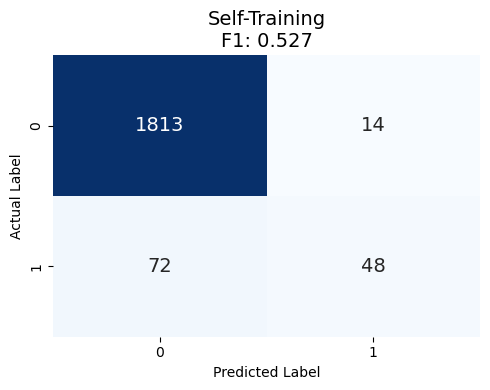

In [6]:
# 補上漏掉的 import
from sklearn.metrics import precision_score, recall_score, roc_auc_score

# 3. Final Training & Test
print("\n🚀 [Phase 4] 最終測試 (Final Test on Clean Data)...")
full_tr_ds = HybridDataset(X_txt_tr, X_stats_tr, y_tr, tokenizer, MAX_LEN)
te_ds = HybridDataset(X_txt_te, X_stats_te, y_te, tokenizer, MAX_LEN)
tr_ld = DataLoader(full_tr_ds, BATCH_SIZE, shuffle=True)
te_ld = DataLoader(te_ds, BATCH_SIZE)

model = HybridMacBERT(MODEL_NAME).to(DEVICE)
opt = AdamW(model.parameters(), lr=LEARNING_RATE)
sch = get_linear_schedule_with_warmup(opt, 0, len(tr_ld)*EPOCHS)

for epoch in range(EPOCHS):
    train_epoch(model, tr_ld, opt, DEVICE, sch, weights)

probs = get_probs(model, te_ld, DEVICE)
labels = y_te

best_f1, best_th = 0, 0.5
for th in np.arange(0.3, 0.8, 0.01):
    f1 = f1_score(labels, (probs>=th).astype(int))
    if f1 > best_f1: best_f1, best_th = f1, th
    
y_pred = (probs >= best_th).astype(int)

# 輸出報告
print("\n" + "="*80)
print(f"🏆 【 Self-Training MacBERT (Clean Data) 訓練結果 】")
print("="*80)
acc = accuracy_score(labels, y_pred)
prec = precision_score(labels, y_pred)
rec = recall_score(labels, y_pred)

print(f"{'Metric':<15} | {'Score':<10}")
print("-" * 30)
print(f"{'Accuracy':<15} | {acc:.4f}")
print(f"{'Precision':<15} | {prec:.4f}")
print(f"{'Recall':<15} | {rec:.4f}")
print(f"{'F1-Score':<15} | {best_f1:.4f}")
print("-" * 30)
print(f"{'5-Fold F1':<15} | {np.mean(fold_scores):.4f}")
print("\n")

print("="*80)
print(f"📌 模型詳細報告：Self-Training (Th={best_th:.2f})")
print("-" * 80)
print(classification_report(labels, y_pred, digits=4))
print("-" * 80)

cm = confusion_matrix(labels, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title(f'Self-Training\nF1: {best_f1:.3f}', fontsize=14)
plt.ylabel('Actual Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()